## Imports

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Structure and shape

In [95]:
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

In [96]:
test.shape[0]

418

In [97]:

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [98]:
train.shape[0]

891

In [99]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [100]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [101]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


### Pre Processing

In [102]:
test.drop(columns=['Cabin'],inplace=True)

In [103]:
train.drop(columns=['Cabin'],inplace=True)

In [104]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [105]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
dtype: int64

In [106]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [107]:
train['Embarked'] = train['Embarked'].fillna('S')

In [108]:
train['Embarked'].isnull().sum()

np.int64(0)

In [109]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [110]:
train['Fare'] = train['Fare'].fillna(train['Fare'].mean())

In [111]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [112]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [113]:
test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

In [114]:
train_Age=np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std(),177)

In [115]:
test_Age=np.random.randint(test['Age'].mean()-test['Age'].std(),test['Age'].mean()+test['Age'].std(),177)

In [116]:
print(train_Age)

[25 39 26 17 40 19 43 24 39 24 28 29 17 19 27 26 19 24 15 33 23 24 36 34
 18 34 22 24 21 22 31 43 39 15 38 30 25 28 20 19 25 34 26 29 18 38 41 36
 22 37 19 34 18 26 18 40 19 16 23 25 34 35 32 37 32 22 22 27 19 26 36 30
 17 41 22 30 17 38 43 41 35 21 31 22 37 33 29 22 23 27 41 18 29 30 38 31
 25 41 34 21 20 32 30 17 17 26 32 40 39 16 27 41 17 30 24 16 17 18 17 29
 31 39 41 32 26 22 22 17 41 20 36 25 43 36 31 19 22 15 17 29 38 23 39 23
 26 39 17 33 33 40 31 19 42 25 42 36 25 18 33 35 24 32 19 43 33 25 28 29
 23 41 40 16 40 43 43 18 19]


In [117]:
print(test_Age)

[41 42 22 36 37 30 23 19 16 43 40 28 38 16 26 26 43 31 19 27 24 28 34 30
 34 36 21 34 19 22 19 19 16 25 21 21 17 23 43 35 27 22 21 36 16 33 33 36
 29 38 40 40 20 39 42 26 28 33 26 31 17 36 43 31 42 20 23 25 39 23 27 40
 21 29 24 43 30 22 30 19 36 35 29 26 41 26 43 25 42 18 30 39 17 43 43 27
 43 42 22 41 43 24 27 16 20 22 18 27 33 36 33 17 22 17 37 37 28 42 29 32
 26 30 34 39 36 33 33 37 23 20 27 30 25 29 31 40 22 17 19 40 31 36 28 37
 19 30 17 31 38 43 16 18 27 36 40 26 38 16 34 26 18 34 38 32 40 33 42 32
 34 43 18 32 28 22 30 25 19]


In [118]:

train.loc[train['Age'].isnull(),'Age']=train_Age.mean()

In [119]:
test.loc[test['Age'].isnull(),'Age']=test_Age.mean()

In [120]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [121]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## EDA

In [122]:
def Survive_ratio(train, x):
    return train[train['Pclass']==x]['Survived'].value_counts()
for i in range(1,4):
    print(Survive_ratio(train, i))

Survived
1    136
0     80
Name: count, dtype: int64
Survived
0    97
1    87
Name: count, dtype: int64
Survived
0    372
1    119
Name: count, dtype: int64


In [123]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [124]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [125]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

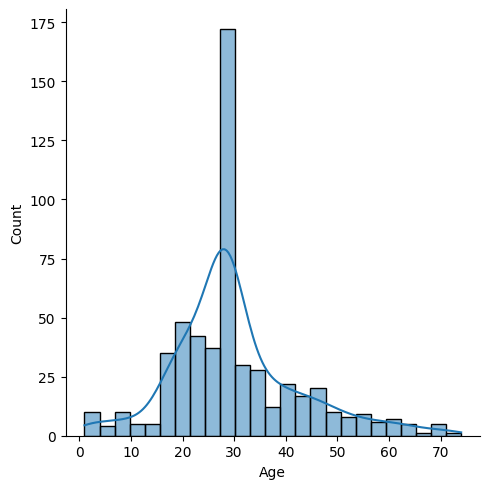

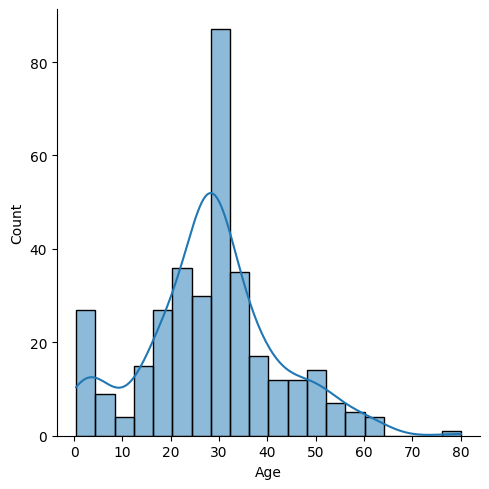

In [126]:
sns.displot(train['Age'][train['Survived']==0],kde=True)
sns.displot(train['Age'][train['Survived']==1],kde=True)

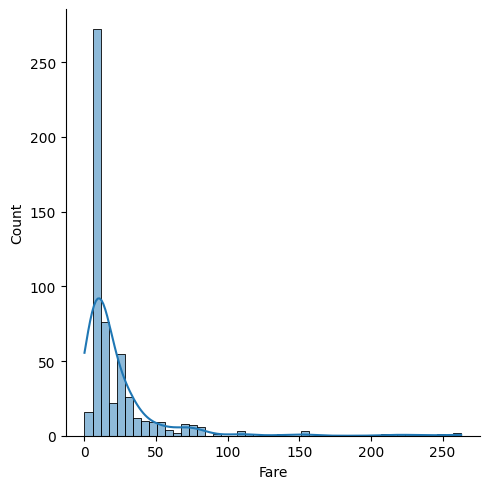

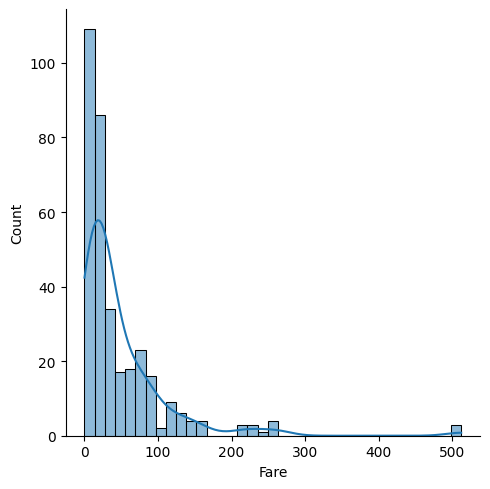

In [127]:
sns.displot(train['Fare'][train['Survived']==0],kde=True)
sns.displot(train['Fare'][train['Survived']==1],kde=True)

In [128]:
train.drop(columns=['Ticket'],inplace=True)
test.drop(columns=['Ticket'],inplace=True)

In [129]:
train['family_size']=train['SibSp']+train['Parch']+1

In [130]:
train['family_size'].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [131]:
test['family_size']=test['SibSp']+test['Parch']+1

In [132]:
test['family_size'].value_counts()

family_size
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [133]:
train.groupby(['family_size'])['Survived'].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [134]:
def calculate(num):
    if num==1:
        return "Alone"
    elif num>1 and num<5:
        return "Medium"
    else:
        return "Large"

In [135]:

train['Family_size_category']=train['family_size'].apply(calculate)

In [136]:
train['Family_size_category'].value_counts()

Family_size_category
Alone     537
Medium    292
Large      62
Name: count, dtype: int64

In [137]:
test['Family_size_category']=test['family_size'].apply(calculate)

In [138]:
test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,family_size,Family_size_category
0,892,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q,1,Alone
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S,2,Medium


In [139]:
train.drop(columns=['SibSp','Parch','family_size'],inplace=True)
test.drop(columns=['SibSp','Parch','family_size'],inplace=True)

In [140]:
print(train.shape)
print(test.shape)

(891, 9)
(418, 8)


In [141]:
passenger_id=test['PassengerId'].values